In [2]:
#02 dimension scores
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#results path
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
#Read standardized data
INPUT_FILE = (
    Path("results")
    / "step_01_04_z_standardised_data.xlsx"
)

INPUT_SHEET = "Standardised_Data"

df = pd.read_excel(
    INPUT_FILE,
    sheet_name=INPUT_SHEET,
    engine="openpyxl",
)

#Define four theoretical dimensions
DIMENSION_INDICATORS = {
    "DEM": [
        "z_Population",
    ],

    "ECO": [
        "z_Total_GDP_PPP",
        "z_GDP_per_capita_PPP",
    ],

    "TRA": [
        "z_Road_Density",
        "z_Railway_Stations",
        "z_Airports",
    ],

    "FUN": [
        "z_Universities",
        "z_Hospitals",
    ],
}

In [4]:
#Calculate the transparent equal-weighted average within the dimension
for dimension, indicators in DIMENSION_INDICATORS.items():
    df[f"{dimension}_raw"] = (
        df[indicators].mean(axis=1)
    )

#Re-standardize the four dimensions ddof=1
for dimension in DIMENSION_INDICATORS:
    raw_column = f"{dimension}_raw"
    standardised_column = f"{dimension}_star"

    dimension_mean = df[raw_column].mean()
    dimension_sd = df[raw_column].std(ddof=1)

    df[standardised_column] = (
        df[raw_column] - dimension_mean
    ) / dimension_sd


DIMENSION_COLUMNS = [
    "DEM_star",
    "ECO_star",
    "TRA_star",
    "FUN_star",
]


In [5]:
#Four-dimensional descriptive statistics
dimension_descriptives = (
    df[DIMENSION_COLUMNS]
    .describe()
    .T
    .reset_index()
    .rename(columns={
        "index": "Dimension",
        "count": "N",
        "mean": "Mean",
        "std": "Sample_SD",
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Maximum",
    })
)

dimension_descriptives["Skewness"] = [
    df[column].skew()
    for column in DIMENSION_COLUMNS
]
print("Four-dimensional descriptive statistics")
print(
    dimension_descriptives.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

print()

# Save table
OUTPUT_FILE = (
    OUTPUT_DIR
    / "Table_5_1_Dimension_Statistics.xlsx"
)

dimension_descriptives.to_excel(
    OUTPUT_FILE,
    index=False,
    sheet_name="Table_5_1",
)

print(f"✓ Table saved: {OUTPUT_FILE}")

Four-dimensional descriptive statistics
Dimension      N   Mean  Sample_SD  Minimum     Q1  Median    Q3  Maximum  Skewness
 DEM_star 56.000  0.000      1.000   -1.312 -0.711  -0.252 0.809    2.593     0.804
 ECO_star 56.000 -0.000      1.000   -1.548 -0.787  -0.019 0.790    2.634     0.481
 TRA_star 56.000  0.000      1.000   -1.885 -0.642  -0.045 0.503    2.546     0.409
 FUN_star 56.000  0.000      1.000   -1.865 -0.736  -0.132 0.621    2.822     0.607

✓ Table saved: results/Table_5_1_Dimension_Statistics.xlsx


In [6]:
#Correlations among the four dimensions
dimension_pearson = df[
    DIMENSION_COLUMNS
].corr(method="pearson")

dimension_spearman = df[
    DIMENSION_COLUMNS
].corr(method="spearman")

print("Four-dimensional Pearson correlation matrix")
print(
    dimension_pearson.to_string(
        float_format=lambda value: f"{value:.3f}"
    )
)
print()
print("Four-dimensional Spearman correlation matrix")
print(
    dimension_spearman.to_string(
        float_format=lambda value: f"{value:.3f}"
    )
)

print()

Four-dimensional Pearson correlation matrix
          DEM_star  ECO_star  TRA_star  FUN_star
DEM_star     1.000     0.720     0.785     0.894
ECO_star     0.720     1.000     0.542     0.572
TRA_star     0.785     0.542     1.000     0.841
FUN_star     0.894     0.572     0.841     1.000

Four-dimensional Spearman correlation matrix
          DEM_star  ECO_star  TRA_star  FUN_star
DEM_star     1.000     0.712     0.769     0.855
ECO_star     0.712     1.000     0.538     0.595
TRA_star     0.769     0.538     1.000     0.796
FUN_star     0.855     0.595     0.796     1.000



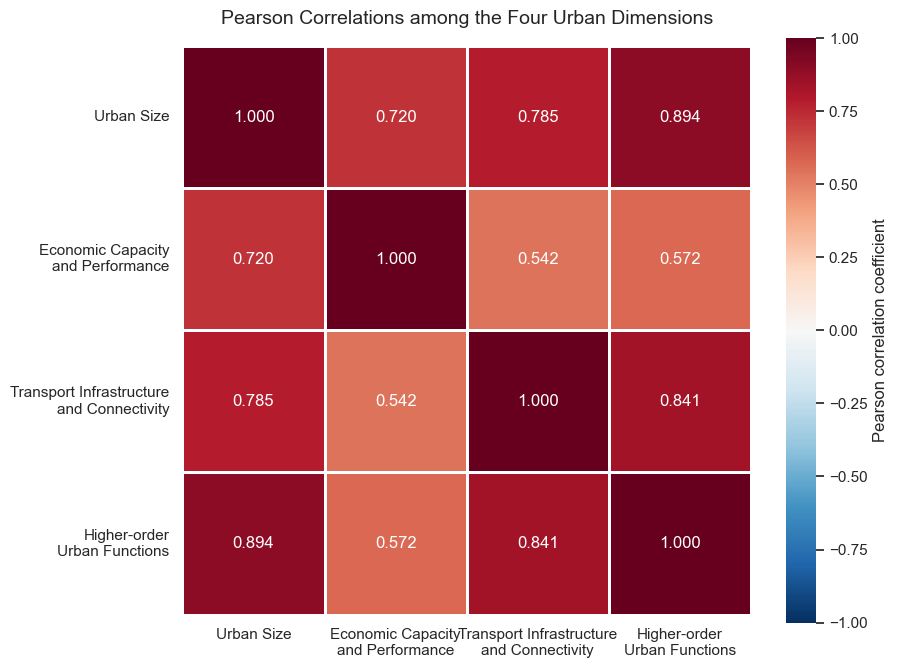

Figure saved to: /Users/cc-hoa/Desktop/毕业论文代码/results/Figure_5_1_four_dimension_pearson_heatmap.png


In [9]:
dimension_columns = [
    "DEM_star",
    "ECO_star",
    "TRA_star",
    "FUN_star",
]

dimension_labels = {
    "DEM_star": "Urban Size",
    "ECO_star": "Economic Capacity\nand Performance",
    "TRA_star": "Transport Infrastructure\nand Connectivity",
    "FUN_star": "Higher-order\nUrban Functions",
}

pearson_corr = df[dimension_columns].corr(method="pearson")

pearson_corr_plot = pearson_corr.rename(
    index=dimension_labels,
    columns=dimension_labels,
)

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    pearson_corr_plot,
    annot=True,              
    fmt=".3f",               
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={
        "label": "Pearson correlation coefficient"
    },
    ax=ax,
)

ax.set_title(
    "Pearson Correlations among the Four Urban Dimensions",
    fontsize=14,
    pad=16,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha="center",
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
)

fig.tight_layout()

OUTPUT_FILE = (
    OUTPUT_DIR
    / "Figure_5_1_four_dimension_pearson_heatmap.png"
)

fig.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {OUTPUT_FILE.resolve()}")

In [18]:
#Correlation diagnosis of the eight indicators
INDICATOR_Z_COLUMNS = [
    "z_Population",
    "z_Total_GDP_PPP",
    "z_GDP_per_capita_PPP",
    "z_Road_Density",
    "z_Railway_Stations",
    "z_Airports",
    "z_Universities",
    "z_Hospitals",
]
indicator_pearson = df[
    INDICATOR_Z_COLUMNS
].corr(method="pearson")

indicator_spearman = df[
    INDICATOR_Z_COLUMNS
].corr(method="spearman")

#Extracting indicators with high absolute correlation coefficients
high_correlation_pairs = []
for row_number in range(
    len(INDICATOR_Z_COLUMNS)
):
    for column_number in range(
        row_number + 1,
        len(INDICATOR_Z_COLUMNS),
    ):
        variable_1 = INDICATOR_Z_COLUMNS[
            row_number
        ]

        variable_2 = INDICATOR_Z_COLUMNS[
            column_number
        ]

        pearson_value = indicator_pearson.loc[
            variable_1,
            variable_2,
        ]

        spearman_value = indicator_spearman.loc[
            variable_1,
            variable_2,
        ]

        high_correlation_pairs.append({
            "Variable_1": variable_1,
            "Variable_2": variable_2,
            "Pearson_r": pearson_value,
            "Spearman_rho": spearman_value,
            "Absolute_Pearson_r": abs(
                pearson_value
            ),
        })


correlation_pairs = pd.DataFrame(
    high_correlation_pairs
).sort_values(
    "Absolute_Pearson_r",
    ascending=False,
)

print("The 10 sets of indicators with the highest correlation")
print(
    correlation_pairs.head(10).to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

print()

The 10 sets of indicators with the highest correlation
        Variable_1         Variable_2  Pearson_r  Spearman_rho  Absolute_Pearson_r
      z_Population    z_Total_GDP_PPP      0.955         0.946               0.955
      z_Population     z_Universities      0.877         0.823               0.877
   z_Total_GDP_PPP     z_Universities      0.865         0.838               0.865
    z_Universities        z_Hospitals      0.850         0.802               0.850
      z_Population        z_Hospitals      0.844         0.811               0.844
z_Railway_Stations        z_Hospitals      0.781         0.707               0.781
z_Railway_Stations     z_Universities      0.770         0.686               0.770
   z_Total_GDP_PPP        z_Hospitals      0.746         0.725               0.746
   z_Total_GDP_PPP         z_Airports      0.746         0.696               0.746
      z_Population z_Railway_Stations      0.694         0.681               0.694



In [19]:
#Representative cities(结果和讨论的时候使用)
representative_rows = []
for dimension_column in DIMENSION_COLUMNS:
    dimension_name = dimension_column.replace(
        "_star",
        "",
    )

    ordered = df.sort_values(
        dimension_column,
        ascending=False,
    )

    highest = ordered.head(5)

    lowest = ordered.tail(5).sort_values(
        dimension_column,
        ascending=True,
    )

    for rank, (_, row) in enumerate(
        highest.iterrows(),
        start=1,
    ):
        representative_rows.append({
            "Dimension": dimension_name,
            "Position_Type": "Highest",
            "Position": rank,
            "ISO3": row["ISO3"],
            "FUA_Code": row["FUA_Code"],
            "FUA_Name": row["FUA_Name"],
            "Dimension_Score": row[
                dimension_column
            ],
        })

    for rank, (_, row) in enumerate(
        lowest.iterrows(),
        start=1,
    ):
        representative_rows.append({
            "Dimension": dimension_name,
            "Position_Type": "Lowest",
            "Position": rank,
            "ISO3": row["ISO3"],
            "FUA_Code": row["FUA_Code"],
            "FUA_Name": row["FUA_Name"],
            "Dimension_Score": row[
                dimension_column
            ],
        })


representative_cities = pd.DataFrame(
    representative_rows
)

print("Representative cities for each dimensions")
print(
    representative_cities.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}",
    )
)

print()

Representative cities for each dimensions
Dimension Position_Type  Position ISO3 FUA_Code                FUA_Name  Dimension_Score
      DEM       Highest         1  JPN   JPN01F                   Tokyo            2.593
      DEM       Highest         2  KOR   KOR01F                   Seoul            2.165
      DEM       Highest         3  USA   USA01F      New York (Greater)            1.984
      DEM       Highest         4  USA   USA02F   Los Angeles (Greater)            1.829
      DEM       Highest         5  JPN   JPN02F                   Osaka            1.793
      DEM        Lowest         1  FRA   FR009F              Strasbourg           -1.312
      DEM        Lowest         2  KOR   KOR08F                Cheongju           -1.273
      DEM        Lowest         3  KOR   KOR07F                   Ulsan           -1.256
      DEM        Lowest         4  CAN   CAN08F                Winnipeg           -1.251
      DEM        Lowest         5  CAN   CAN07F                  Que

In [20]:
#Comprehensive Four-Dimensional Score Table for All Cities
city_dimension_scores = df[
    [
        "ID",
        "Country",
        "ISO3",
        "Rank_in_Country",
        "FUA_Code",
        "FUA_Name",
        "Core_City",
        "DEM_raw",
        "ECO_raw",
        "TRA_raw",
        "FUN_raw",
        "DEM_star",
        "ECO_star",
        "TRA_star",
        "FUN_star",
    ]
].copy()

In [21]:
#Generate rankings separately for each dimension
for dimension in [
    "DEM",
    "ECO",
    "TRA",
    "FUN",
]:
    city_dimension_scores[
        f"{dimension}_rank"
    ] = (
        city_dimension_scores[
            f"{dimension}_star"
        ]
        .rank(
            ascending=False,
            method="min",
        )
        .astype(int)
    )

In [22]:
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_EXCEL = (
    OUTPUT_DIR
    / "step_02_dimension_scores.xlsx"
)

OUTPUT_CSV = (
    OUTPUT_DIR
    / "step_02_dimension_scores.csv"
)

with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl",
) as writer:

    city_dimension_scores.to_excel(
        writer,
        sheet_name="Dimension_Scores",
        index=False,
    )

    dimension_descriptives.to_excel(
        writer,
        sheet_name="Dimension_Descriptives",
        index=False,
    )

    dimension_pearson.to_excel(
        writer,
        sheet_name="Dimension_Pearson",
    )

    dimension_spearman.to_excel(
        writer,
        sheet_name="Dimension_Spearman",
    )

    indicator_pearson.to_excel(
        writer,
        sheet_name="Indicator_Pearson",
    )

    indicator_spearman.to_excel(
        writer,
        sheet_name="Indicator_Spearman",
    )

    correlation_pairs.to_excel(
        writer,
        sheet_name="Correlation_Pairs",
        index=False,
    )

    representative_cities.to_excel(
        writer,
        sheet_name="Representative_Cities",
        index=False,
    )

city_dimension_scores.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig",
)
print(f"✓ Excel saved to: {OUTPUT_EXCEL}")
print(f"✓ CSV saved to: {OUTPUT_CSV}")

✓ Excel saved to: results/step_02_dimension_scores.xlsx
✓ CSV saved to: results/step_02_dimension_scores.csv


✓ Figure saved to: results/step_02_indicator_correlations.png


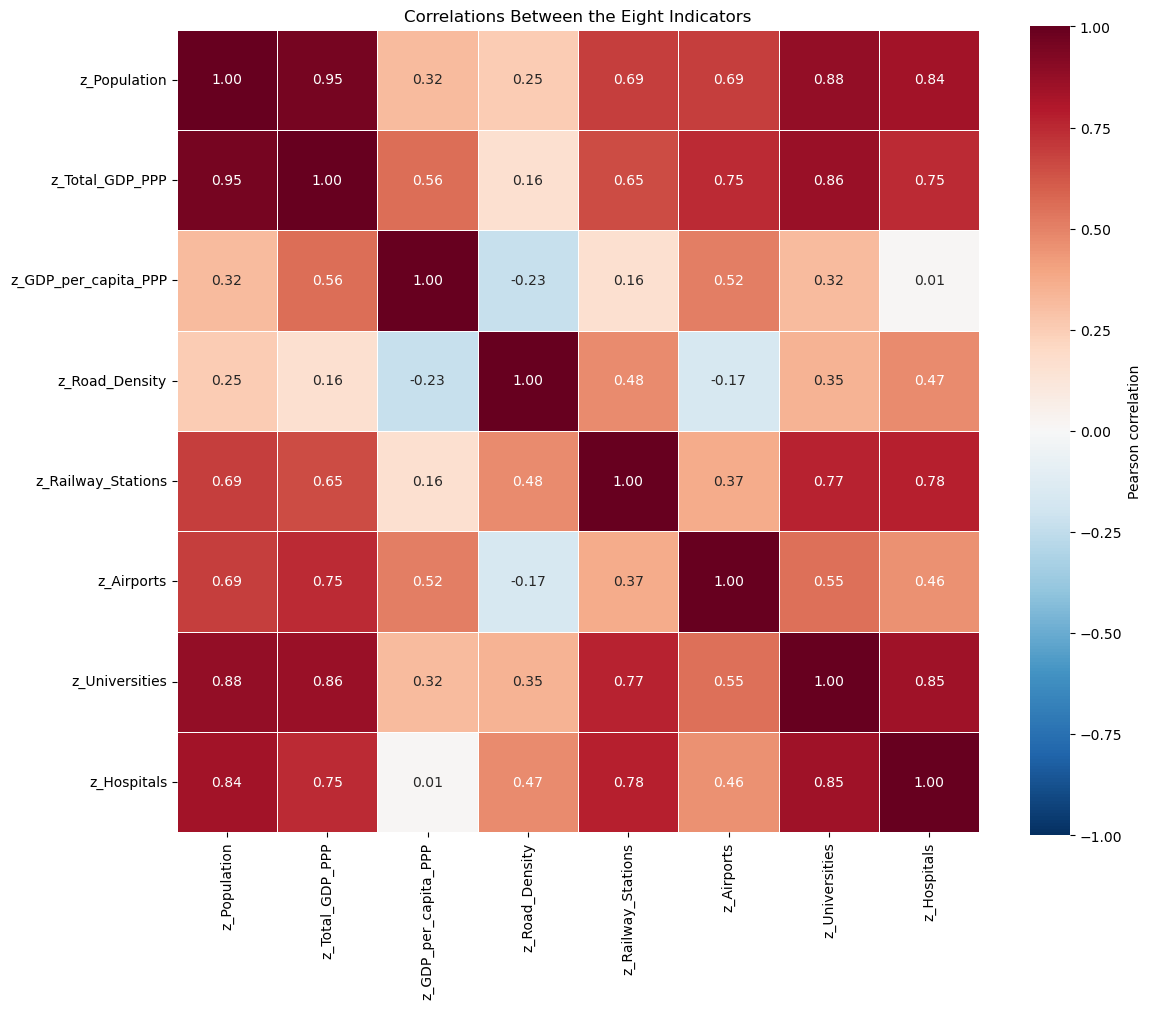

In [23]:
#Correlation Heatmap of Eight Indicators
fig, axis = plt.subplots(
    figsize=(12, 10),
)

sns.heatmap(
    indicator_pearson,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={
        "label": "Pearson correlation",
    },
    ax=axis,
)

axis.set_title(
    "Correlations Between the Eight Indicators"
)

fig.tight_layout()

# Save figure
INDICATOR_CORRELATION_FIGURE = (
    OUTPUT_DIR
    / "step_02_indicator_correlations.png"
)

fig.savefig(
    INDICATOR_CORRELATION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)
print(f"✓ Figure saved to: {INDICATOR_CORRELATION_FIGURE}")
plt.show()
plt.close(fig)

✓ Figure saved to: results/step_02_city_dimension_profiles.png


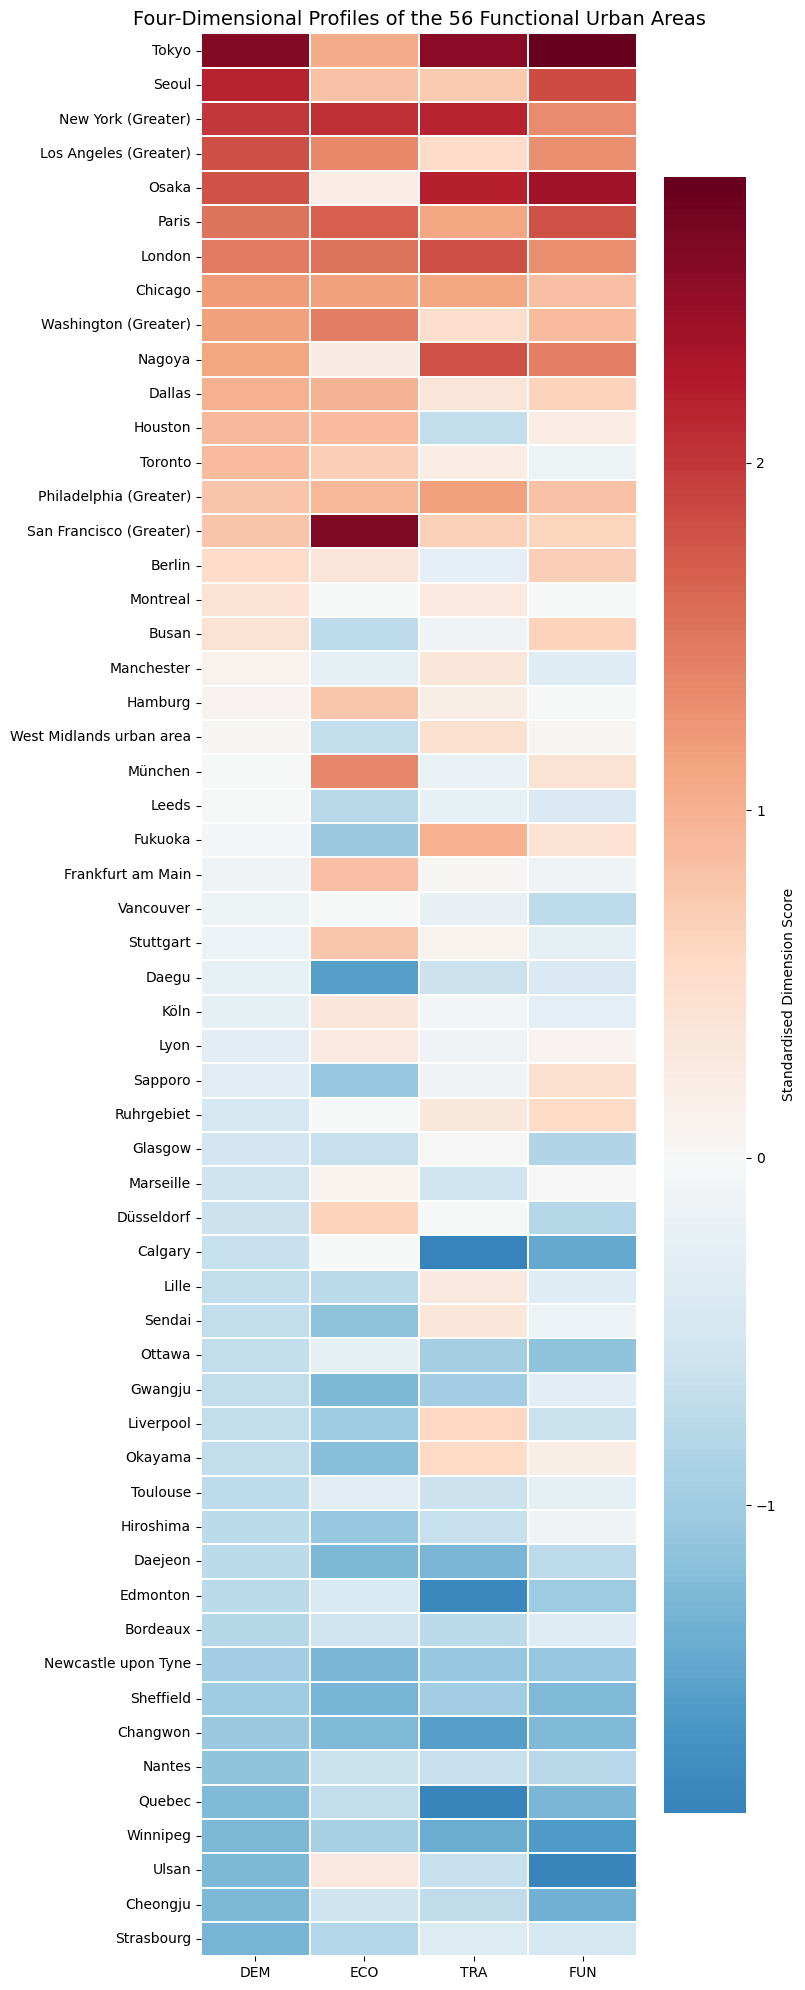

In [24]:
#Four-dimensional profiles of the 56 FUAs
#Cities are ordered by DEM only(no UHI ranking)
heatmap_data = (
    city_dimension_scores
    .sort_values(
        by="DEM_star",
        ascending=False,
    )
    .set_index("FUA_Name")[
        DIMENSION_COLUMNS
    ]
)

heatmap_data = heatmap_data.rename(
    columns={
        "DEM_star": "DEM",
        "ECO_star": "ECO",
        "TRA_star": "TRA",
        "FUN_star": "FUN",
    }
)

fig, axis = plt.subplots(
    figsize=(8, 20),
)

sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={
        "label": "Standardised Dimension Score",
    },
    ax=axis,
)

axis.set_title(
    "Four-Dimensional Profiles of the 56 Functional Urban Areas",
    fontsize=14,
)

axis.set_xlabel("")
axis.set_ylabel("")

fig.tight_layout()

# Save figure
DIMENSION_PROFILE_FIGURE = (
    OUTPUT_DIR
    / "step_02_city_dimension_profiles.png"
)

fig.savefig(
    DIMENSION_PROFILE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

print(f"✓ Figure saved to: {DIMENSION_PROFILE_FIGURE}")
plt.show()
plt.close(fig)

In [25]:
# 16. Standardisation check
dimension_check = pd.DataFrame({
    "Dimension": DIMENSION_COLUMNS,
    "Mean": [
        df[column].mean()
        for column in DIMENSION_COLUMNS
    ],
    "Sample_SD": [
        df[column].std(ddof=1)
        for column in DIMENSION_COLUMNS
    ],
})

print("=" * 90)
print("Standardisation check")
print("=" * 90)

print(
    dimension_check.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)

print()
print("Step 02 completed successfully")
print(f"Excel output : {OUTPUT_EXCEL}")
print(f"CSV output   : {OUTPUT_CSV}")
print(f"Figure       : {DIMENSION_PROFILE_FIGURE}")
print()
print("No UHI, Tier or Archetype has been calculated at this stage.")

Standardisation check
Dimension      Mean  Sample_SD
 DEM_star  0.000000   1.000000
 ECO_star -0.000000   1.000000
 TRA_star  0.000000   1.000000
 FUN_star  0.000000   1.000000

Step 02 completed successfully
Excel output : results/step_02_dimension_scores.xlsx
CSV output   : results/step_02_dimension_scores.csv
Figure       : results/step_02_city_dimension_profiles.png

No UHI, Tier or Archetype has been calculated at this stage.
